# Eksplorasi Data (NO<sub>2</sub> Semarang)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\USERB-PC\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\traitlet

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

## Membaca Dataset

In [3]:
df = pd.read_csv('../data/data-copernicus/timeseries.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df

,date,feature_index,NO2
66,2023-12-31 00:00:00+00:00,0,NaN
64,2024-01-01 00:00:00+00:00,0,NaN
65,2024-01-02 00:00:00+00:00,0,NaN
67,2024-01-03 00:00:00+00:00,0,NaN
68,2024-01-04 00:00:00+00:00,0,0.000015
...,...,...,...
108,2024-04-26 00:00:00+00:00,0,NaN
79,2024-04-27 00:00:00+00:00,0,NaN
81,2024-04-28 00:00:00+00:00,0,0.000050
78,2024-04-29 00:00:00+00:00,0,0.000047


## Jumlah Missing Value

C:\Users\USERB-PC\AppData\Local\Temp\ipykernel_16284\286252978.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


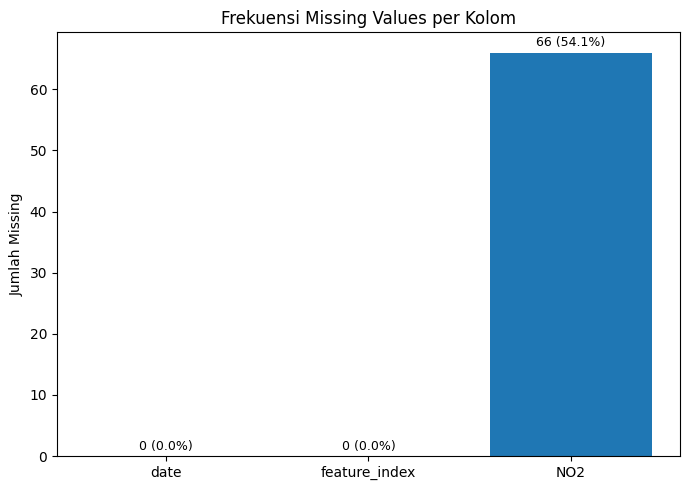

,Missing Count,Missing Percent (%)
date,0,0.0
feature_index,0,0.0
NO2,66,54.1


In [4]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table


## Statistik deskriptif

In [5]:
desc = df.describe()
desc

,feature_index,NO2
count,122.0,56.000000
mean,0.0,0.000040
std,0.0,0.000016
min,0.0,0.000015
25%,0.0,0.000033
50%,0.0,0.000038
75%,0.0,0.000045
max,0.0,0.000098


## Tabel Informasi Dataset

In [10]:
info_table = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str),
    "Jumlah Data Tidak Kosong": len(df) - df.isna().sum(),
    "Jumlah Missing": df.isna().sum()
})
info_table

,Kolom,Tipe Data,Jumlah Data Tidak Kosong,Jumlah Missing
date,date,"datetime64[ns, UTC]",122,0
feature_index,feature_index,int64,122,0
NO2,NO2,float64,56,66


## Visualisasi Time Series NO₂

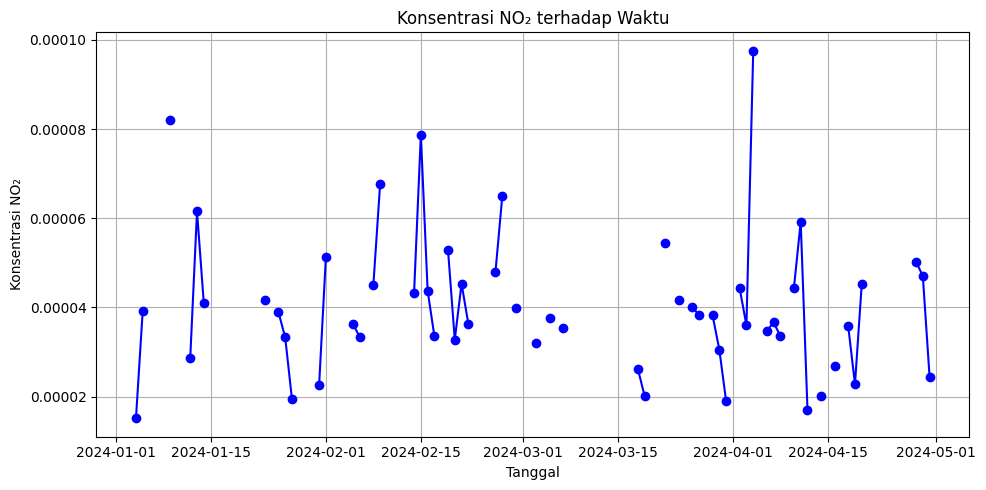

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['NO2'], marker='o', linestyle='-', color='blue')
plt.title("Konsentrasi NO₂ terhadap Waktu")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.tight_layout()
plt.show()